In [ ]:
from IPython.display import Image
Image(url= "https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png", width=700)

In [66]:
import numpy as np
import torch
import torchvision
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn as nn
from tqdm import tqdm
from torch import optim

In [67]:
class VOCSegLoader(torchvision.datasets.VOCSegmentation):
  def __init__(self,
               root,
               year = '2012',
               image_set = 'train',
               download = False,
               transform=None,
               target_transform=None,
               transforms=None):

    super(VOCSegLoader,self).__init__(root, year, image_set, download, transform, target_transform, transforms)

  def __getitem__(self, index):
    img = Image.open(self.images[index]).convert('RGB')
    target = Image.open(self.masks[index]).convert('L')

    target = np.array(target)
    target[target==255] = 0
    target = Image.fromarray(target)

    if self.transforms is not None:
      img, target = self.transforms(img, target)

    target = torch.as_tensor(np.asarray(target, dtype = np.uint8), dtype = torch.long)
    return img, target


In [99]:
import torchvision.transforms as transforms

_epochs = 3
batch_size_train = 100
batch_size_val = 100
learning_rate = 0.001
momentum = 0.9
log_interval = 10
image_size = (512, 512)

transform_data = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor()
])
transform_label = transforms.Compose([
    transforms.Resize(image_size, interpolation = 0)
])

train_dataset = VOCSegLoader('./data', year = '2012', image_set = 'train', download = True, transform = transform_data, target_transform = transform_label)
val_dataset = VOCSegLoader ('./data', year = '2012', image_set = 'val', download = True, transform = transform_data, target_transform = transform_label)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size_train)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size = batch_size_val)



Using downloaded and verified file: ./data/VOCtrainval_11-May-2012.tar
Extracting ./data/VOCtrainval_11-May-2012.tar to ./data
Using downloaded and verified file: ./data/VOCtrainval_11-May-2012.tar
Extracting ./data/VOCtrainval_11-May-2012.tar to ./data


Visualizing 5 samples from the training set:
Input shape: torch.Size([3, 512, 512])
Input shape: torch.Size([3, 512, 512])
Input shape: torch.Size([3, 512, 512])
Input shape: torch.Size([3, 512, 512])
Input shape: torch.Size([3, 512, 512])


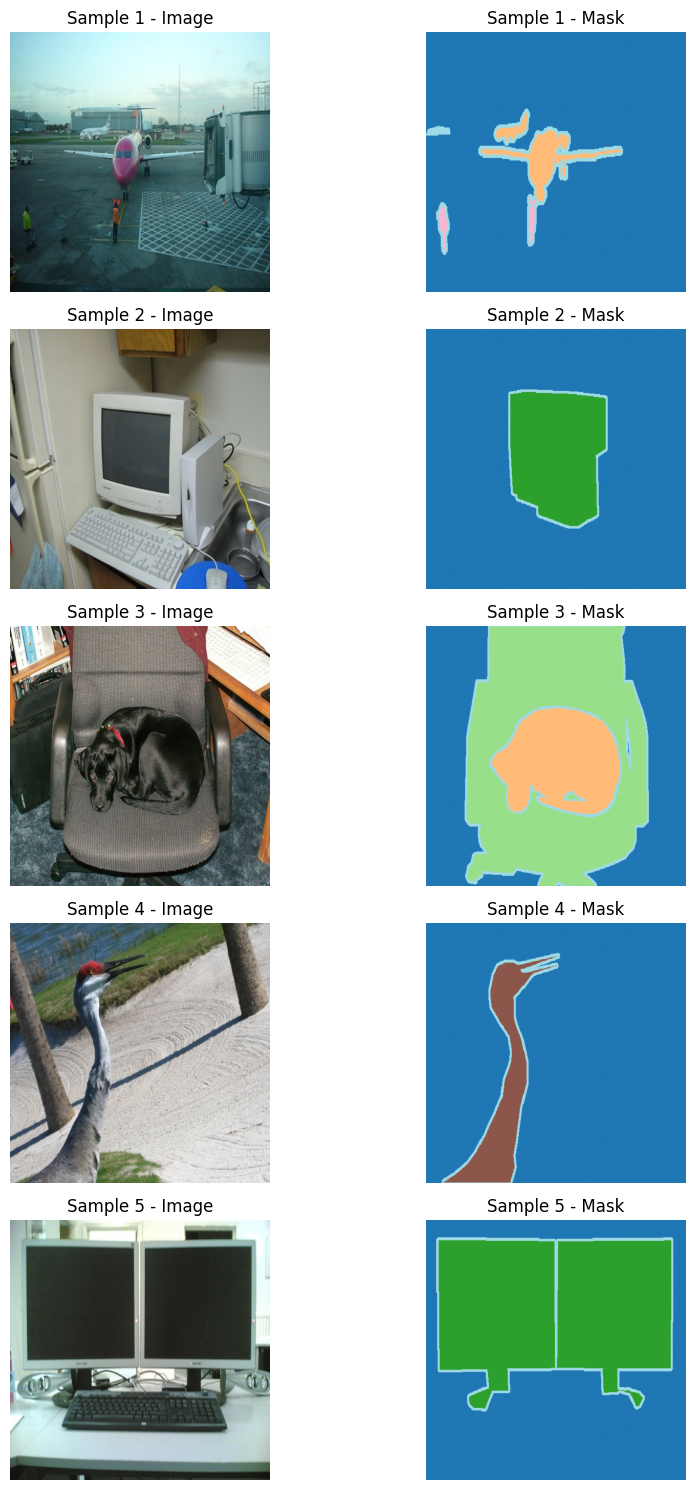

In [100]:
def visualize(dataloader, num_samples):
  dataiter = iter(dataloader)
  images, masks = next(dataiter)
  fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 3))

  for idx in range (num_samples):
    img = images[idx]
    mask = masks[idx]
    print(f"Input shape: {img.shape}")
    img_display = to_pil_image(img)
    axes[idx, 0].imshow(img_display)
    axes[idx, 0 ].set_title(f'Sample {idx + 1} - Image')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(mask.numpy(), cmap = 'tab20')
    axes[idx, 1].set_title(f'Sample {idx + 1} - Mask')
    axes[idx, 1].axis('off')

  plt.tight_layout()
  plt.show()

print("Visualizing 5 samples from the training set:")
visualize(train_loader, num_samples=5)

dataiter = iter(train_loader)
images, masks = next(dataiter)

In [70]:
device = ("cuda"
          if torch.cuda.is_available()
          else "mps"
          if torch.backends.mps.is_available()
          else "cpu"
          )

In [101]:
class DoubleConv(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv_op = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
      )

  def forward(self, x):
    return self.conv_op(x)

class DownSample(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv = DoubleConv(in_channels, out_channels)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    down = self.conv(x)
    p = self.pool(down)

    return down, p


class UpSample(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
    self.conv = DoubleConv(in_channels, out_channels)

  def forward(self, x1, x2):
    x1 = self.up(x1)

    x = torch.cat([x1, x2], 1)
    return self.conv(x)

In [102]:
class UNet(nn.Module):
  def __init__(self, input_channels, num_classes):
    super().__init__()
    self.down_conv1 = DownSample(input_channels, 64)
    self.down_conv2 = DownSample(64, 128)
    self.down_conv3 = DownSample(128, 256)
    self.down_conv4 = DownSample(256, 512)

    self.buttle_neck = DoubleConv(512, 1024)

    self.up_trans1 = UpSample(1024, 512)
    self.up_trans2 = UpSample(512, 256)
    self.up_trans3 = UpSample(256, 128)
    self.up_trans4 = UpSample(128, 64)

    self.output = nn.Conv2d(64, num_classes, kernel_size = 1)

  def forward(self, x):
      t1, down1 = self.down_conv1(x)
      print(f"t1: {t1.shape}, down1: {down1.shape}")

      t2, down2 = self.down_conv2(down1)
      print(f"t2: {t2.shape}, down2: {down2.shape}")

      t3, down3 = self.down_conv3(down2)
      print(f"t3: {t3.shape}, down3: {down3.shape}")

      t4, down4 = self.down_conv4(down3)
      print(f"t4: {t4.shape}, down4: {down4.shape}")

      b = self.buttle_neck(down4)
      print(f"bottleneck: {b.shape}")

      up1 = self.up_trans1(b, t4)
      print(f"up1: {up1.shape}")

      up2 = self.up_trans2(up1, t3)
      print(f"up2: {up2.shape}")

      up3 = self.up_trans3(up2, t2)
      print(f"up3: {up3.shape}")

      up4 = self.up_trans4(up3, t1)
      print(f"up4: {up4.shape}")

      out = self.output(up4)
      print(f"out: {out.shape}")
      return out





In [103]:
conv = DoubleConv(256,256)

image = images[0]
image = image.unsqueeze(0)
mask = masks[0]
print(f"Input shape: {image.shape}")
input_image = torch.rand((1,3,512,512))
print(f"Input shape: {input_image.shape}")
model = UNet(3,10)
output = model(image)

Input shape: torch.Size([1, 3, 512, 512])
Input shape: torch.Size([1, 3, 512, 512])
t1: torch.Size([1, 64, 512, 512]), down1: torch.Size([1, 64, 256, 256])
t2: torch.Size([1, 128, 256, 256]), down2: torch.Size([1, 128, 128, 128])
t3: torch.Size([1, 256, 128, 128]), down3: torch.Size([1, 256, 64, 64])
t4: torch.Size([1, 512, 64, 64]), down4: torch.Size([1, 512, 32, 32])
bottleneck: torch.Size([1, 1024, 32, 32])
up1: torch.Size([1, 512, 64, 64])
up2: torch.Size([1, 256, 128, 128])
up3: torch.Size([1, 128, 256, 256])
up4: torch.Size([1, 64, 512, 512])
out: torch.Size([1, 10, 512, 512])


In [113]:
model = UNet(3,num_classes= 21).to(device)
optimizer = optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.BCEWithLogitsLoss()

for epoch in tqdm(range(_epochs)):
  model.train()
  train_loss = 0
  for idx, img_mask in enumerate(tqdm(train_dataset)):
    img = img_mask[0].float().to(device)
    mask = img_mask[1].float().to(device)

    img = img.unsqueeze(0)

    pred = model(img)
    optimizer.zero_grad


    pred = pred.squeeze(0)


    loss = criterion(pred, mask)
    train_loss = loss.item()

    loss.backward()
    optimizer.step()

  train_loss += train_loss/(idx + 1)

  model.eval()
  val_loss = 0

  with torch.no_grad():
    for idx, img_mask in enumerate(tqdm(val_dataset)):
      img = img_mask[0].float().to(device)
      mask = img_mask[1].float().to(device)

      pred = model(img)
      loss = criterion(pred, mask)

      val_loss += loss

    val_loss = val_loss/(idx + 1)
    print(f"train loss {epoch + 1 }: {train_loss:.4f}")
    print(f"val loss {epoch +1}: {val_loss:.4f}")



  0%|          | 0/3 [00:00<?, ?it/s]

t1: torch.Size([1, 64, 512, 512]), down1: torch.Size([1, 64, 256, 256])
t2: torch.Size([1, 128, 256, 256]), down2: torch.Size([1, 128, 128, 128])
t3: torch.Size([1, 256, 128, 128]), down3: torch.Size([1, 256, 64, 64])
t4: torch.Size([1, 512, 64, 64]), down4: torch.Size([1, 512, 32, 32])
bottleneck: torch.Size([1, 1024, 32, 32])
up1: torch.Size([1, 512, 64, 64])
up2: torch.Size([1, 256, 128, 128])
up3: torch.Size([1, 128, 256, 256])
up4: torch.Size([1, 64, 512, 512])
out: torch.Size([1, 21, 512, 512])


ValueError: Target size (torch.Size([512, 512])) must be the same as input size (torch.Size([21, 512, 512]))